### xgboost参数

- 选择较高的学习速率(learning rate)。一般情况下，学习速率的值为0.1。但是，对于不同的问题，理想的学习速率有时候会在0.05到0.3之间波动。选择对应于此学习速率的理想决策树数量。XGBoost有一个很有用的函数“cv”，这个函数可以在每一次迭代中使用交叉验证，并返回理想的决策树数量。 


- 对于给定的学习速率和决策树数量，进行决策树特定参数调优(max_depth, min_child_weight, gamma, subsample, colsample_bytree)。在确定一棵树的过程中，我们可以选择不同的参数，待会儿我会举例说明。  


- xgboost的正则化参数的调优。(lambda, alpha)。这些参数可以降低模型的复杂度，从而提高模型的表现。  


- 降低学习速率，确定理想参数。

#### xgboost的使用方法
* ①使用xgboost自带的数据集格式 + xgboost自带的建模方式
    * 把数据读取成xgb.DMatrix格式(libsvm/dataframe.values给定X和Y)
    * 准备好一个watch_list(观测和评估的数据集)
    * xgb.train(dtrain)
    * xgb.predict(dtest)
* ②使用pandas的DataFrame格式 + xgboost的sklearn接口
    * estimator = xgb.XGBClassifier()/xgb.XGBRegressor()
    * estimator.fit(df_train.values, df_target.values)

In [6]:
#!/usr/bin/python
import os
import numpy as np
#import scipy.sparse
import pickle
import xgboost as xgb

# 基本例子，从libsvm文件中读取数据，做二分类
# 数据是libsvm的格式
#1 3:1 10:1 11:1 21:1 30:1 34:1 36:1 40:1 41:1 53:1 58:1 65:1 69:1 77:1 86:1 88:1 92:1 95:1 102:1 105:1 117:1 124:1
#0 3:1 10:1 20:1 21:1 23:1 34:1 36:1 39:1 41:1 53:1 56:1 65:1 69:1 77:1 86:1 88:1 92:1 95:1 102:1 106:1 116:1 120:1
#0 1:1 10:1 19:1 21:1 24:1 34:1 36:1 39:1 42:1 53:1 56:1 65:1 69:1 77:1 86:1 88:1 92:1 95:1 102:1 106:1 116:1 122:1
dtrain = xgb.DMatrix('./data/agaricus.txt.train?format=libsvm')
dtest = xgb.DMatrix('./data/agaricus.txt.test?format=libsvm')

#超参数设定
param = {'max_depth':2, 'eta':1, 'silent':1, 'objective':'binary:logistic' }

# 设定watchlist用于查看模型状态
watchlist  = [(dtest,'eval'), (dtrain,'train')]
num_round = 2
bst = xgb.train(param, dtrain, num_round, watchlist)

# 使用模型预测
preds = bst.predict(dtest)

# 判断准确率
labels = dtest.get_label()
print ('错误类为%f' % \
       (sum(1 for i in range(len(preds)) if int(preds[i]>0.5)!=labels[i]) /float(len(preds))))

# 模型存储
os.makedirs('./model', exist_ok=True)
bst.save_model('./model/0001.model')

[0]	eval-logloss:0.22646	train-logloss:0.23316
[1]	eval-logloss:0.13776	train-logloss:0.13654
错误类为0.021726


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:59:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/var/folders/tp/23bv8cd51qx1cp4g6vj6nr_r0000gn/T/ipykernel_51649/569508341.py:34: UserWarning: [21:59:24] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  bst.save_model('./model/0001.model')


#### 2.配合pandas DataFrame格式数据建模

In [9]:
# 皮马印第安人糖尿病数据集 包含很多字段：怀孕次数 口服葡萄糖耐量试验中血浆葡萄糖浓度 舒张压（mm Hg） 三头肌组织褶厚度（mm） 
# 2小时血清胰岛素（μU/ ml） 体重指数（kg/（身高(m)^2） 糖尿病系统功能 年龄（岁）
import pandas as pd
data = pd.read_csv('./data/Pima-Indians-Diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
#!/usr/bin/python
import numpy as np
import pandas as pd
import pickle
import xgboost as xgb
from sklearn.model_selection import train_test_split

# 基本例子，从csv文件中读取数据，做二分类

# 用pandas读入数据
data = pd.read_csv('./data/Pima-Indians-Diabetes.csv')

# 做数据切分
train, test = train_test_split(data)

# 转换成Dmatrix格式
feature_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
target_column = 'Outcome'
xgtrain = xgb.DMatrix(train[feature_columns].values, train[target_column].values)
xgtest = xgb.DMatrix(test[feature_columns].values, test[target_column].values)

#参数设定
param = {'max_depth':5, 'eta':0.1, 'silent':1, 'subsample':0.7, 'colsample_bytree':0.7, 'objective':'binary:logistic' }

# 设定watchlist用于查看模型状态
watchlist  = [(xgtest,'eval'), (xgtrain,'train')]
num_round = 10
bst = xgb.train(param, xgtrain, num_round, watchlist)

# 使用模型预测
preds = bst.predict(xgtest)

# 判断准确率
labels = xgtest.get_label()
print ('错误类为%f' % \
       (sum(1 for i in range(len(preds)) if int(preds[i]>0.5)!=labels[i]) /float(len(preds))))

# 模型存储
bst.save_model('./model/0002.model')

[0]	eval-logloss:0.60594	train-logloss:0.61989
[1]	eval-logloss:0.59806	train-logloss:0.59868
[2]	eval-logloss:0.58193	train-logloss:0.57601
[3]	eval-logloss:0.57435	train-logloss:0.55683
[4]	eval-logloss:0.56802	train-logloss:0.54126
[5]	eval-logloss:0.56280	train-logloss:0.52855
[6]	eval-logloss:0.55776	train-logloss:0.51324
[7]	eval-logloss:0.55345	train-logloss:0.49837
[8]	eval-logloss:0.55007	train-logloss:0.48768
[9]	eval-logloss:0.53590	train-logloss:0.47217
错误类为0.250000


/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py:748: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [22:06:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/var/folders/tp/23bv8cd51qx1cp4g6vj6nr_r0000gn/T/ipykernel_51649/3904989020.py:39: UserWarning: [22:06:17] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  bst.save_model('./model/0002.model')


#### 3.使用xgboost的sklearn包

In [12]:
#!/usr/bin/python
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import pickle
import xgboost as xgb
from sklearn.model_selection import train_test_split
import joblib


# 基本例子，从csv文件中读取数据，做二分类

# 用pandas读入数据
data = pd.read_csv('./data/Pima-Indians-Diabetes.csv')

# 做数据切分
train, test = train_test_split(data)

# 取出特征X和目标y的部分
feature_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
target_column = 'Outcome'
train_X = train[feature_columns].values
train_y = train[target_column].values
test_X = test[feature_columns].values
test_y = test[target_column].values

# 初始化模型
xgb_classifier = xgb.XGBClassifier(n_estimators=20,\
                                   max_depth=4, \
                                   learning_rate=0.1, \
                                   subsample=0.7, \
                                   colsample_bytree=0.7)

# 拟合模型
xgb_classifier.fit(train_X, train_y)

# 使用模型预测
preds = xgb_classifier.predict(test_X)

# 判断准确率
print ('错误类为%f' %((preds!=test_y).sum()/float(test_y.shape[0])))

# 模型存储
joblib.dump(xgb_classifier, './model/0003.model')

错误类为0.265625


['./model/0003.model']

#### 4.交叉验证

In [13]:
xgb.cv(param, dtrain, num_round, nfold=5,metrics={'error'}, seed = 0)

,train-error-mean,train-error-std,test-error-mean,test-error-std
0,0.003109,0.000927,0.004914,0.001506
1,0.004030,0.000697,0.006142,0.001086
2,0.002879,0.000718,0.004145,0.001855
3,0.002380,0.000448,0.003992,0.002025
4,0.000844,0.000431,0.001228,0.001041
5,0.001996,0.000509,0.003378,0.001424
6,0.000921,0.000506,0.001228,0.001041
7,0.001228,0.000260,0.001228,0.001041
8,0.000921,0.000506,0.001228,0.001041
9,0.000921,0.000506,0.001228,0.001041


#### 5.添加预处理的交叉验证

In [14]:
# 计算正负样本比，调整样本权重
def fpreproc(dtrain, dtest, param):
    label = dtrain.get_label()
    ratio = float(np.sum(label == 0)) / np.sum(label==1)
    param['scale_pos_weight'] = ratio
    return (dtrain, dtest, param)

# 先做预处理，计算样本权重，再做交叉验证
xgb.cv(param, dtrain, num_round, nfold=5,
       metrics={'auc'}, seed = 0, fpreproc = fpreproc)

,train-auc-mean,train-auc-std,test-auc-mean,test-auc-std
0,0.998026,0.000335,0.997228,0.001656
1,1.000000,0.000000,1.000000,0.000000
2,1.000000,0.000000,1.000000,0.000000
3,0.999998,0.000004,0.999994,0.000011
4,0.999998,0.000004,0.999994,0.000011
5,0.999998,0.000004,0.999994,0.000011
6,1.000000,0.000000,1.000000,0.000000
7,1.000000,0.000000,1.000000,0.000000
8,1.000000,0.000000,1.000000,0.000000
9,1.000000,0.000000,1.000000,0.000000


#### 6.自定义损失函数与评估准则

In [ ]:
print ('running cross validation, with cutomsized loss function')
# 自定义损失函数，需要提供损失函数的一阶导和二阶导
def logregobj(preds, dtrain):
    labels = dtrain.get_label()
    preds = 1.0 / (1.0 + np.exp(-preds))
    grad = preds - labels
    hess = preds * (1.0-preds)
    return grad, hess

# 自定义评估准则，评估预估值和标准答案之间的差距
def evalerror(preds, dtrain):
    labels = dtrain.get_label()
    return 'error', float(sum(labels != (preds > 0.0))) / len(labels)

watchlist  = [(dtest,'eval'), (dtrain,'train')]
param = {'max_depth':3, 'eta':0.1, 'silent':1}
num_round = 5
# 自定义损失函数训练
bst = xgb.train(param, dtrain, num_round, watchlist, logregobj, evalerror)
# 交叉验证（新版 xgb.cv 不支持 obj/feval，此处用 param 中的 objective 做 cv）
xgb.cv(param, dtrain, num_boost_round=num_round, nfold=5, seed=0)
# 将收益作为模型目标去训练模型，是不是更好？ 不是因为上线后，还是会跟策略有关，如果模型训练的目标跟收益绑定，那么策略就不能发生变化
# 所以模型一般都是站在人会变坏概率的风险角度去训练，然后通过策略调整来达到一个最大收益

running cross validation, with cutomsized loss function
[0]	eval-rmse:0.30690	train-rmse:0.30616
[1]	eval-rmse:0.17919	train-rmse:0.17728
[2]	eval-rmse:0.17257	train-rmse:0.17173
[3]	eval-rmse:0.26961	train-rmse:0.27111
[4]	eval-rmse:0.39690	train-rmse:0.39826


,train-rmse-mean,train-rmse-std,test-rmse-mean,test-rmse-std
0,0.453144,0.001021,0.453161,0.001028
1,0.411323,0.000935,0.411553,0.001178
2,0.373881,0.000801,0.374071,0.000758
3,0.340559,0.000217,0.340627,0.000580
4,0.310777,0.000538,0.311195,0.001098


#### 7.只用前n颗树预测

In [18]:
#!/usr/bin/python
import numpy as np
import pandas as pd
import pickle
import xgboost as xgb
from sklearn.model_selection import train_test_split

# 基本例子，从csv文件中读取数据，做二分类

# 用pandas读入数据
data = pd.read_csv('./data/Pima-Indians-Diabetes.csv')

# 做数据切分
train, test = train_test_split(data)

# 转换成Dmatrix格式
feature_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
target_column = 'Outcome'
xgtrain = xgb.DMatrix(train[feature_columns].values, train[target_column].values)
xgtest = xgb.DMatrix(test[feature_columns].values, test[target_column].values)

#参数设定
param = {'max_depth':5, 'eta':0.1, 'silent':1, 'subsample':0.7, 'colsample_bytree':0.7, 'objective':'binary:logistic' }

# 设定watchlist用于查看模型状态
watchlist  = [(xgtest,'eval'), (xgtrain,'train')]
num_round = 10
bst = xgb.train(param, xgtrain, num_round, watchlist)

# 只用第1颗树预测
ypred1 = bst.predict(xgtest, iteration_range=(0, 1))
# 用前9颗树预测
ypred2 = bst.predict(xgtest, iteration_range=(0, 9))
label = xgtest.get_label()
print ('用前1颗树预测的错误率为 %f' % (np.sum((ypred1>0.5)!=label) /float(len(label))))
print ('用前9颗树预测的错误率为 %f' % (np.sum((ypred2>0.5)!=label) /float(len(label))))

[0]	eval-logloss:0.60985	train-logloss:0.61695
[1]	eval-logloss:0.59369	train-logloss:0.59966
[2]	eval-logloss:0.57276	train-logloss:0.57613


[3]	eval-logloss:0.55763	train-logloss:0.55704
[4]	eval-logloss:0.54789	train-logloss:0.54242
[5]	eval-logloss:0.53779	train-logloss:0.53021
[6]	eval-logloss:0.53055	train-logloss:0.51858
[7]	eval-logloss:0.52338	train-logloss:0.50635
[8]	eval-logloss:0.51735	train-logloss:0.49678
[9]	eval-logloss:0.50235	train-logloss:0.47997
用前1颗树预测的错误率为 0.338542
用前9颗树预测的错误率为 0.239583


### sklearn与Xgboost配合使用
#### 1.Xgboost建模，sklearn评估

In [22]:
import pickle
import xgboost as xgb

import numpy as np
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, mean_squared_error
from sklearn.datasets import load_iris, load_digits, load_diabetes

rng = np.random.RandomState(31337)

#二分类：混淆矩阵
print("数字0和1的二分类问题")
digits = load_digits(n_class=2)
y = digits['target']
X = digits['data']
kf = KFold(n_splits=2, shuffle=True, random_state=rng)
print("在2折数据上的交叉验证")
for train_index, test_index in kf.split(X):
    xgb_model = xgb.XGBClassifier().fit(X[train_index],y[train_index])
    predictions = xgb_model.predict(X[test_index])
    actuals = y[test_index]
    print("混淆矩阵:")
    print(confusion_matrix(actuals, predictions))

#多分类：混淆矩阵
print("\nIris: 多分类")
iris = load_iris()
y = iris['target']
X = iris['data']
kf = KFold(n_splits=2, shuffle=True, random_state=rng)
print("在2折数据上的交叉验证")
for train_index, test_index in kf.split(X):
    xgb_model = xgb.XGBClassifier().fit(X[train_index],y[train_index])
    predictions = xgb_model.predict(X[test_index])
    actuals = y[test_index]
    print("混淆矩阵:")
    print(confusion_matrix(actuals, predictions))

#回归问题：MSE
print("\n波士顿房价回归预测问题")
# 使用 load_diabetes 避免 fetch_california_housing 联网下载时的 403
boston = load_diabetes()
y = boston['target']
X = boston['data']
kf = KFold(n_splits=2, shuffle=True, random_state=rng)
print("在2折数据上的交叉验证")
for train_index, test_index in kf.split(X):
    xgb_model = xgb.XGBRegressor().fit(X[train_index],y[train_index])
    predictions = xgb_model.predict(X[test_index])
    actuals = y[test_index]
    print("MSE:",mean_squared_error(actuals, predictions))

数字0和1的二分类问题
在2折数据上的交叉验证
混淆矩阵:
[[87  0]
 [ 1 92]]
混淆矩阵:
[[91  0]
 [ 3 86]]

Iris: 多分类
在2折数据上的交叉验证
混淆矩阵:
[[19  0  0]
 [ 1 31  2]
 [ 0  3 19]]
混淆矩阵:
[[31  0  0]
 [ 0 16  0]
 [ 0  1 27]]

波士顿房价回归预测问题
在2折数据上的交叉验证
MSE: 3822.999845972513
MSE: 3823.672522882323


#### 2.网格搜索查找最优超参数

In [23]:
# 第2种训练方法的 调参方法：使用sklearn接口的regressor + GridSearchCV
print("参数最优化：")
y = boston['target']
X = boston['data']
xgb_model = xgb.XGBRegressor()
param_dict = {'max_depth': [2,4,6],
              'n_estimators': [50,100,200]}

clf = GridSearchCV(xgb_model, param_dict, verbose=1)
clf.fit(X,y)
print(clf.best_score_)
print(clf.best_params_)

参数最优化：
Fitting 5 folds for each of 9 candidates, totalling 45 fits
0.4235412673564447
{'max_depth': 2, 'n_estimators': 50}


#### 3.early-stopping 早停

In [ ]:
# 第1/2种训练方法的 调参方法：early stopping
# 在训练集上学习模型，一颗一颗树添加，在验证集上看效果，当验证集效果不再提升，停止树的添加与生长
X = digits['data']
y = digits['target']
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=0)
clf = xgb.XGBClassifier(early_stopping_rounds=10, eval_metric="auc")
clf.fit(X_train, y_train, eval_set=[(X_val, y_val)]) # 超过10轮，验证集上KS不再提升，·停止树的添加与生长

[0]	validation_0-auc:0.99020
[1]	validation_0-auc:0.99975
[2]	validation_0-auc:0.99975
[3]	validation_0-auc:0.99975
[4]	validation_0-auc:0.99975
[5]	validation_0-auc:0.99975
[6]	validation_0-auc:1.00000
[7]	validation_0-auc:1.00000
[8]	validation_0-auc:1.00000
[9]	validation_0-auc:1.00000
[10]	validation_0-auc:1.00000
[11]	validation_0-auc:1.00000
[12]	validation_0-auc:1.00000
[13]	validation_0-auc:1.00000
[14]	validation_0-auc:1.00000
[15]	validation_0-auc:1.00000
[16]	validation_0-auc:1.00000


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

#### 4.特征重要度

特征排序：
特征 petal_length 重要度为 0.676586
特征 petal_width 重要度为 0.297366
特征 sepal_width 重要度为 0.016450
特征 sepal_length 重要度为 0.009598


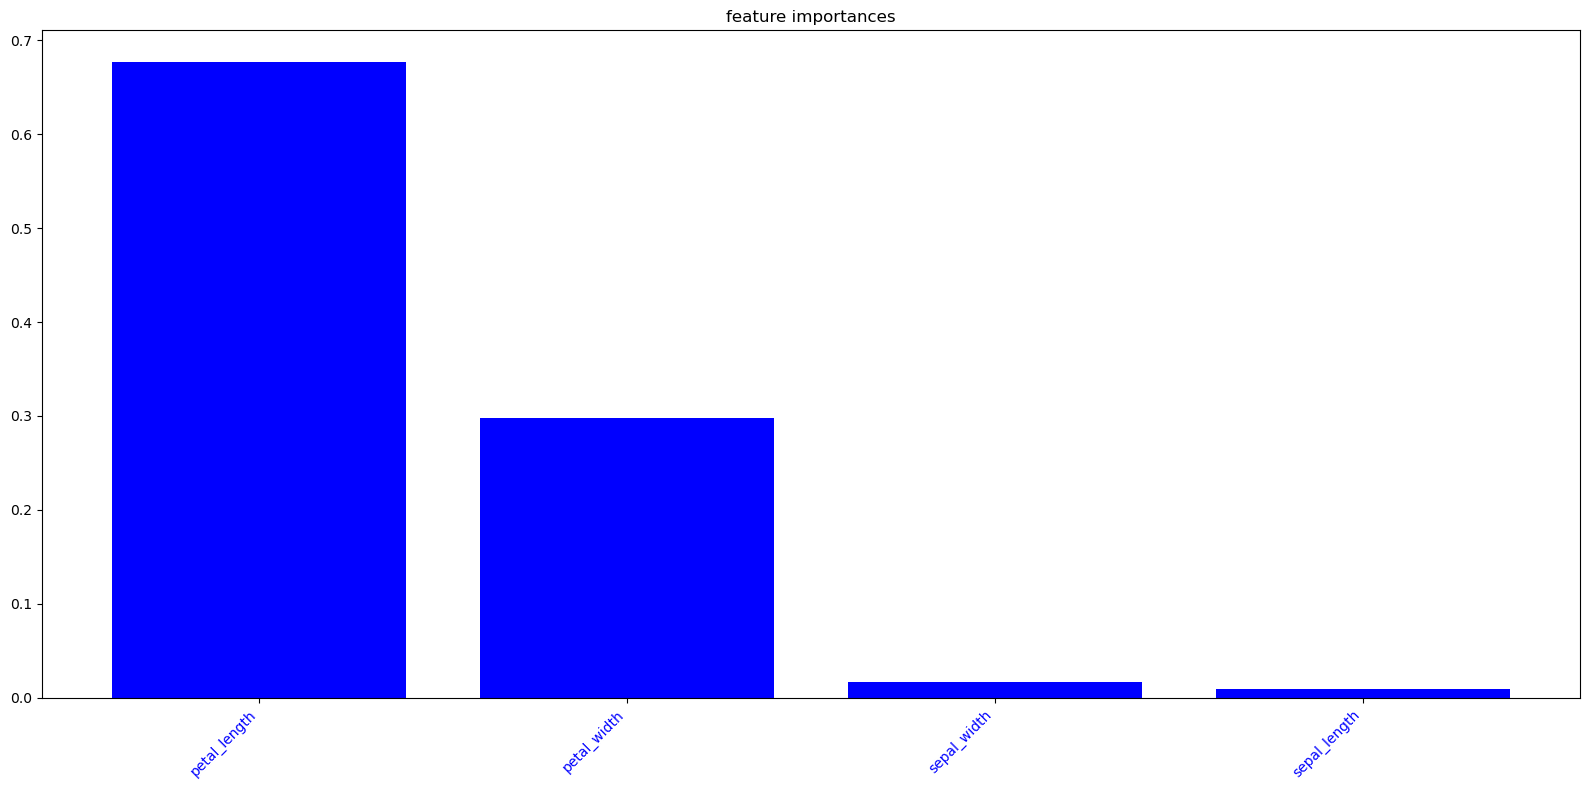

Exception ignored in: <function ResourceTracker.__del__ at 0x1058c9f80>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105be1f80>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [ ]:
iris = load_iris()
y = iris['target']
X = iris['data']
xgb_model = xgb.XGBClassifier().fit(X,y)

print('特征排序：')
feature_names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
feature_importances = xgb_model.feature_importances_
indices = np.argsort(feature_importances)[::-1]

for index in indices:
    print("特征 %s 重要度为 %f" %(feature_names[index], feature_importances[index]))

%matplotlib inline
import matplotlib.pyplot as plt
plt.close('all')  # 关闭已有图形，避免重复运行 cell 时出现多张图
plt.figure(figsize=(16, 8))
plt.title("feature importances")
plt.bar(range(len(feature_importances)), feature_importances[indices], color='b')
plt.xticks(range(len(feature_importances)), np.array(feature_names)[indices], color='b', rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 5.并行训练加速

In [30]:
import os

if __name__ == "__main__":
    try:
        from multiprocessing import set_start_method
        set_start_method("forkserver")
    except ImportError:
        raise ImportError("Unable to import multiprocessing.set_start_method."
                          " This example only runs on Python 3.4")
    except RuntimeError:
        pass  # context has already been set (e.g. in Jupyter)

    import numpy as np
    from sklearn.model_selection import GridSearchCV
    from sklearn.datasets import load_diabetes
    import xgboost as xgb

    rng = np.random.RandomState(31337)

    print("Parallel Parameter optimization")
    boston = load_diabetes()  # load_boston 已移除

    os.environ["OMP_NUM_THREADS"] = "2"  # or to whatever you want
    y = boston['target']
    X = boston['data']
    xgb_model = xgb.XGBRegressor()
    clf = GridSearchCV(xgb_model, {'max_depth': [2, 4, 6],
                                   'n_estimators': [50, 100, 200]}, verbose=1,
                       n_jobs=2)
    clf.fit(X, y)
    print(clf.best_score_)
    print(clf.best_params_)

Parallel Parameter optimization
Fitting 5 folds for each of 9 candidates, totalling 45 fits


0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
1906.99s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
1907.02s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
1907.02s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - Debugger warni

0.4235412673564447
{'max_depth': 2, 'n_estimators': 50}
